In [1]:
# !wget https://www.ncei.noaa.gov/data/global-hourly/archive/csv/2024.tar.gz

In [2]:
# !mkdir /home/ryanltz2000/dsa5208_proj2/2024_Dataset
# !tar xf 2024.tar.gz -C /home/ryanltz2000/dsa5208_proj2/2024_Dataset

In [3]:
# !rm 2024.tar.gz

## Load Raw Data

In [4]:
import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer

import matplotlib.pyplot as plt
import seaborn as sns

spark= SparkSession \
       .builder \
       .appName("DSA5208_Proj2") \
       .getOrCreate()

spark

In [2]:
print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
spark.sparkContext.getConf().getAll()

Spark master: local[*]
Default parallelism: 12


[('spark.driver.extraJavaOptions',
  '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED -Djdk.reflect.useDirectMethodHandle=false'),
 ('spark.app.submitTime', '1762174597684'),
 ('spark.executor.id', 'driver'),
 ('spark.app.name', 'DSA5

In [ ]:
df = spark.read.csv("2024_Dataset/", header=True, inferSchema=True)

In [6]:
df = df.select("STATION",
               "DATE",
               "SOURCE",
               "LATITUDE",
               "LONGITUDE",
               "ELEVATION",
               "NAME",
               "REPORT_TYPE",
               "CALL_SIGN",
               "QUALITY_CONTROL",
               "WND",
               "CIG",
               "VIS",
               "TMP",
               "DEW",
               "SLP")

In [5]:
df.show(20)

+-----------+-------------------+------+--------+---------+---------+--------------------+-----------+---------+---------------+--------------+-----------+------------+-------+-------+-------+
|    STATION|               DATE|SOURCE|LATITUDE|LONGITUDE|ELEVATION|                NAME|REPORT_TYPE|CALL_SIGN|QUALITY_CONTROL|           WND|        CIG|         VIS|    TMP|    DEW|    SLP|
+-----------+-------------------+------+--------+---------+---------+--------------------+-----------+---------+---------------+--------------+-----------+------------+-------+-------+-------+
|99999963894|2024-01-01T00:00:00|     I| 34.7728| -87.6399|    161.5|MUSCLE SHOALS 2 N...|      CRN05|    99999|           V020|211,1,H,0018,1|99999,9,9,N|999999,9,9,9|+0105,1|+9999,9|99999,9|
|99999963894|2024-01-01T00:05:00|     I| 34.7728| -87.6399|    161.5|MUSCLE SHOALS 2 N...|      CRN05|    99999|           V020|214,1,H,0017,1|99999,9,9,N|999999,9,9,9|+0100,1|+9999,9|99999,9|
|99999963894|2024-01-01T00:10:00|  

We remove Source, Name, call sign, report type or station number as these are identifiers/specification of sensors or reports, as these are not desired predictive features for our model. Quality Control, which is a specification of Quality control system is also removed.

In [7]:
df = df.select("DATE",
               "LATITUDE",
               "LONGITUDE",
               "ELEVATION",
               "WND",
               "CIG",
               "VIS",
               "TMP",
               "DEW",
               "SLP")

In [ ]:
df.printSchema()

root
 |-- DATE: string (nullable = true)
 |-- LATITUDE: string (nullable = true)
 |-- LONGITUDE: string (nullable = true)
 |-- ELEVATION: string (nullable = true)
 |-- WND: string (nullable = true)
 |-- CIG: string (nullable = true)
 |-- VIS: string (nullable = true)
 |-- TMP: string (nullable = true)
 |-- DEW: string (nullable = true)
 |-- SLP: string (nullable = true)



Check if there are any nulls in each column

In [ ]:
# Count nulls (NAs) in each column
na_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

na_counts.show()

+----+--------+---------+---------+---+---+---+---+---+---+
|DATE|LATITUDE|LONGITUDE|ELEVATION|WND|CIG|VIS|TMP|DEW|SLP|
+----+--------+---------+---------+---+---+---+---+---+---+
|   0|       0|        0|        0|  0|  0|  0|  0|  0|  0|
+----+--------+---------+---------+---+---+---+---+---+---+



## Drop NA/nulls from the target variable TMP

In [10]:
# drop NA for TMP 
df_clean_target = df.na.drop(subset=["TMP"])

In [11]:
#Parsing temperature 
df_clean_target =  df_clean_target.withColumn('TMP' , F.split(F.col("TMP"), ",")) \
.withColumn('TMP_VALUE', F.col('TMP').getItem(0).cast(T.FloatType())) \
.withColumn('TMP_QUALITY', F.col('TMP').getItem(1)).drop('TMP')

In [18]:
df_clean_target.groupBy('TMP_QUALITY').count().show()

+-----------+--------+
|TMP_QUALITY|   count|
+-----------+--------+
|          9| 4160259|
|          1|94354506|
|          2|  121509|
|          5|27986868|
|          6|   40046|
|          C| 3523505|
|          A|    9524|
|          7|   25823|
|          P|      66|
+-----------+--------+



In [12]:
df_TEMP_filter = df_clean_target.filter((F.col('TMP_VALUE') >= -932) & (F.col('TMP_VALUE') <= 618)).filter(F.col('TMP_QUALITY').isin(['0','1','4','5','9','A', 'C', 'I' ,'M', 'P', 'R', 'U']))\
    .drop('TMP_QUALITY')

In [9]:
df_TEMP_filter.count()

125874469

## Correlation Analysis

### Correlation of Wind and TMP

In [28]:
#format WND colum 
# Item 0 is direction, item 2 is a CODE, item 3 is speed]

df_wind_split = df_TEMP_filter.withColumn("WND", F.split(F.col("WND"), ",")).\
    withColumn("WND_DIR", F.col("WND").getItem(0).cast(T.FloatType()))\
    .withColumn("WND_DIR_QUALITY", F.col("WND").getItem(1).cast(T.IntegerType()))\
    .withColumn("WND_DIR_CODE", F.col("WND").getItem(2))\
    .withColumn("WND_SPEED", F.col("WND").getItem(3).cast(T.FloatType()))\
    .withColumn("WND_SPEED_QUALITY", F.col("WND").getItem(4).cast(T.IntegerType()))\
    .drop("WND")

In [13]:
df_wind_split.groupBy("WND_DIR_CODE").count().show()

+------------+--------+
|WND_DIR_CODE|   count|
+------------+--------+
|           9|19680016|
|           H| 1156705|
|           R| 1208449|
|           V| 9456550|
|           C|13065699|
|           N|81307050|
+------------+--------+



In [29]:
df_wind_clean = df_wind_split.filter((F.col("WND_DIR") <= 360) & (F.col("WND_DIR") >= 0))\
    .filter(F.col("WND_DIR_QUALITY").isin([0,1,4,5,9]))\
    .filter((F.col("WND_SPEED") >= 0) & (F.col("WND_SPEED") <= 900))\
    .filter(F.col("WND_SPEED_QUALITY").isin([0,1,4,5,9]))\
    .drop('WND_DIR_QUALITY', 'WND_SPEED_QUALITY')

df_wind_clean = df_wind_clean.filter((F.col('WND_DIR_CODE') != '9') | (F.col('WND_SPEED') == 0))

In [10]:
df_wind_clean.groupBy("WND_DIR_CODE").count().show()

+------------+--------+
|WND_DIR_CODE|   count|
+------------+--------+
|           H| 1156705|
|           V| 5884950|
|           N|80690234|
|           9|  170599|
+------------+--------+



In [11]:
df_wind_clean.printSchema()

root
 |-- DATE: string (nullable = true)
 |-- LATITUDE: string (nullable = true)
 |-- LONGITUDE: string (nullable = true)
 |-- ELEVATION: string (nullable = true)
 |-- CIG: string (nullable = true)
 |-- VIS: string (nullable = true)
 |-- DEW: string (nullable = true)
 |-- SLP: string (nullable = true)
 |-- TMP_VALUE: float (nullable = true)
 |-- WND_DIR: float (nullable = true)
 |-- WND_DIR_CODE: string (nullable = true)
 |-- WND_SPEED: float (nullable = true)



In [30]:
indexer = StringIndexer(inputCol="WND_DIR_CODE", outputCol="WND_DIR_CODE_NUM")
df_wind_clean = indexer.fit(df_wind_clean).transform(df_wind_clean)
df_wind_clean.printSchema()

root
 |-- DATE: string (nullable = true)
 |-- LATITUDE: string (nullable = true)
 |-- LONGITUDE: string (nullable = true)
 |-- ELEVATION: string (nullable = true)
 |-- CIG: string (nullable = true)
 |-- VIS: string (nullable = true)
 |-- DEW: string (nullable = true)
 |-- SLP: string (nullable = true)
 |-- TMP_VALUE: float (nullable = true)
 |-- WND_DIR: float (nullable = true)
 |-- WND_DIR_CODE: string (nullable = true)
 |-- WND_SPEED: float (nullable = true)
 |-- WND_DIR_CODE_NUM: double (nullable = false)



In [31]:
# Columns
cols = ["WND_DIR", "WND_DIR_CODE_NUM", "WND_SPEED", "TMP_VALUE"]

# Compute correlation matrix in Spark
corr_matrix_wind = []
for i in range(len(cols)):
    row = []
    for j in range(len(cols)):
        corr_val = df_wind_clean.stat.corr(cols[i], cols[j])
        row.append(corr_val)
    corr_matrix_wind.append(row)

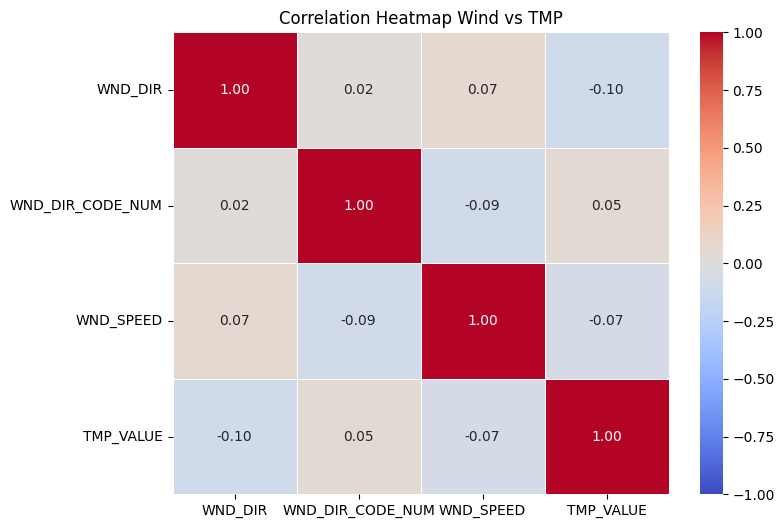

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_wind, 
            annot=True, 
            cmap = "coolwarm",
            fmt=".2f", 
            xticklabels=cols,
            yticklabels=cols, 
            linewidths=0.5, 
            vmin = -1, 
            vmax = 1)
plt.title("Correlation Heatmap Wind vs TMP")
plt.show()

In [19]:
df_wind_clean_speed_only = df_wind_split\
    .filter((F.col("WND_SPEED") >= 0) & (F.col("WND_SPEED") <= 900))\
    .filter(F.col("WND_SPEED_QUALITY").isin([0,1,4,5,9]))

In [21]:
wind_speed_corr_value = df_wind_clean_speed_only.stat.corr("WND_SPEED", "TMP_VALUE")
print("Correlation between Wind Speed and TMP: ", wind_speed_corr_value)

Correlation between Wind Speed and TMP:  -0.03900726835848995


In [20]:
df_wind_clean_dir_only = df_wind_split\
    .filter((F.col("WND_DIR") <= 360) & (F.col("WND_DIR") >= 0))\
    .filter(F.col("WND_DIR_QUALITY").isin([0,1,4,5,9]))\
    .filter((F.col('WND_DIR_CODE') != '9') | (F.col('WND_SPEED') == 0))

In [22]:
wind_direction_corr_value = df_wind_clean_dir_only.stat.corr("WND_DIR", "TMP_VALUE")
print("Correlation between Wind Direction and TMP: ", wind_direction_corr_value)

Correlation between Wind Direction and TMP:  -0.09883338354732715


In [23]:
indexer = StringIndexer(inputCol="WND_DIR_CODE", outputCol="WND_DIR_CODE_NUM")
df_wind_clean_dir_only = indexer.fit(df_wind_clean_dir_only).transform(df_wind_clean_dir_only)

In [24]:
wind_direction_code_corr_value = df_wind_clean_dir_only.stat.corr("WND_DIR_CODE_NUM", "TMP_VALUE")
print("Correlation between Wind Direction Code and TMP: ", wind_direction_code_corr_value)

Correlation between Wind Direction Code and TMP:  0.04838662117397005


### Correlation of CIG and TMP

In [33]:
# Parse the CIG column. The only point of interested is the lowest ceiling height of 
# obscuring phenomena layer /cloud cover. The third field is metadata which is not 
# important, and if it is missing it should not affect the analysis.
#  the last field signifies whether CAVOK (Ceiling And Visibility OK) has been 
# reported by the system, which is a key indicator.

df_CIG_split = df_TEMP_filter.withColumn("CIG", F.split(F.col("CIG"), ","))\
    .withColumn("CIG_HEIGHT", F.col("CIG").getItem(0).cast(T.FloatType()))\
    .withColumn("CIG_HEIGHT_QUALITY",  F.col("CIG").getItem(1).cast(T.IntegerType()))\
    .withColumn("CIG_CAVOK", F.col("CIG").getItem(3))\
    .drop("CIG")


In [22]:
df_CIG_split.groupBy("CIG_CAVOK").count().show()

+---------+---------+
|CIG_CAVOK|    count|
+---------+---------+
|        N|105151883|
|        9| 14450357|
|        Y|  6272229|
+---------+---------+



In [12]:
df_CIG_split.groupBy("CIG_HEIGHT").count().orderBy(F.desc("CIG_HEIGHT")).show(10)

+----------+--------+
|CIG_HEIGHT|   count|
+----------+--------+
|   99999.0|64902669|
|   22000.0|29238958|
|   21336.0|       2|
|   19812.0|       1|
|   18288.0|       3|
|   15240.0|       4|
|   15000.0|      28|
|   14990.0|       1|
|   14710.0|       1|
|   14680.0|       1|
+----------+--------+
only showing top 10 rows



In [34]:
df_CIG_clean = df_CIG_split.filter(F.col("CIG_HEIGHT") != 99999.0).filter(F.col("CIG_CAVOK") != "9").filter(F.col("CIG_HEIGHT_QUALITY").isin([0,1,4,5,9]))


In [14]:
df_CIG_clean.count()

58200249

In [35]:
df_CIG_clean = df_CIG_clean.withColumn(
    "CIG_CAVOK_NUM",
    F.when(F.col("CIG_CAVOK") == "Y", 1).otherwise(0).cast(T.FloatType())
)

In [36]:
# Columns
cols = ["CIG_CAVOK_NUM", "CIG_HEIGHT", "TMP_VALUE"]

# Compute correlation matrix in Spark
corr_matrix_CIG = []
for i in range(len(cols)):
    row = []
    for j in range(len(cols)):
        corr_val = df_CIG_clean.stat.corr(cols[i], cols[j])
        row.append(corr_val)
    corr_matrix_CIG.append(row)


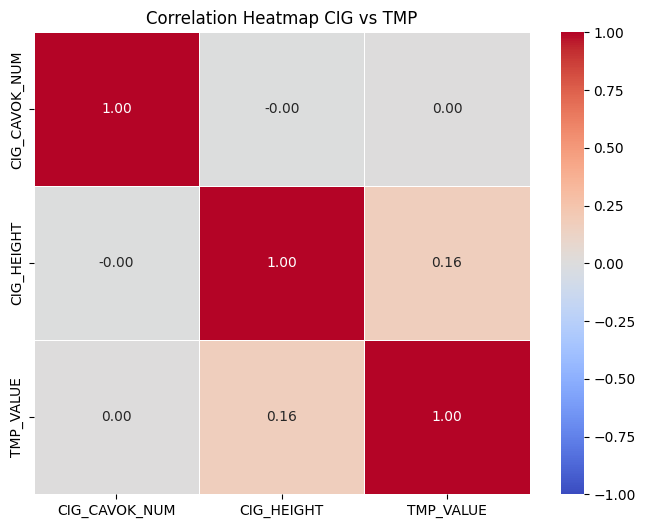

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_CIG, 
            annot=True, 
            cmap = "coolwarm", 
            fmt=".2f", 
            xticklabels=cols, 
            yticklabels=cols, 
            linewidths=0.5, 
            vmin=-1, 
            vmax=1)
plt.title("Correlation Heatmap CIG vs TMP")
plt.show()

In [18]:
df_CIG_clean_height_only = df_CIG_split.filter(F.col("CIG_HEIGHT") != 99999.0)

In [19]:
cig_height_corr_value = df_CIG_clean_height_only.stat.corr("CIG_HEIGHT", "TMP_VALUE")
print("Correlation between CIG Height and TMP: ", cig_height_corr_value)

Correlation between CIG Height and TMP:  0.1667996512489467


In [20]:
df_CIG_cavok_only = df_CIG_split.filter(F.col("CIG_CAVOK") != "9")

In [21]:
df_CIG_cavok_only = df_CIG_cavok_only.withColumn(
    "CIG_CAVOK_NUM",
    F.when(F.col("CIG_CAVOK") == "Y", 1).otherwise(0).cast(T.FloatType())
)

In [23]:
cig_cavok_corr_value = df_CIG_cavok_only.stat.corr("CIG_CAVOK_NUM", "TMP_VALUE")
print("Correlation between CIG CAVOK and TMP: ", cig_cavok_corr_value)

Correlation between CIG CAVOK and TMP:  0.07065874956376852


### Correlation between SLP and TMP

In [38]:
df_SLP_split = df_TEMP_filter.withColumn('SLP' , F.split(F.col("SLP"), ",")) \
.withColumn('SLP_VALUE', F.col('SLP').getItem(0).cast(T.FloatType())) \
.withColumn('SLP_QUALITY', F.col('SLP').getItem(1).cast(T.IntegerType())).drop('SLP')

In [39]:
df_SLP_clean = df_SLP_split.filter(F.col('SLP_QUALITY').isin([0,1,4,5,9]))\
    .filter(F.col('SLP_VALUE') != 99999.0)\
    .drop('SLP_QUALITY')

In [24]:
df_SLP_clean.printSchema()

root
 |-- DATE: string (nullable = true)
 |-- LATITUDE: string (nullable = true)
 |-- LONGITUDE: string (nullable = true)
 |-- ELEVATION: string (nullable = true)
 |-- WND: string (nullable = true)
 |-- CIG: string (nullable = true)
 |-- VIS: string (nullable = true)
 |-- DEW: string (nullable = true)
 |-- TMP_VALUE: float (nullable = true)
 |-- SLP_VALUE: float (nullable = true)



In [25]:
df_SLP_clean.count()

51481912

In [33]:
slp_tmp_corr_value = df_SLP_clean.stat.corr("SLP_VALUE", "TMP_VALUE")
print("Correlation between SLP and TMP: ", slp_tmp_corr_value)

Correlation between SLP and TMP:  -0.20968752412444477


In [40]:
# Columns
cols = ["SLP_VALUE", "TMP_VALUE"]

# Compute correlation matrix in Spark
corr_matrix_SLP = []
for i in range(len(cols)):
    row = []
    for j in range(len(cols)):
        corr_val = df_SLP_clean.stat.corr(cols[i], cols[j])
        row.append(corr_val)
    corr_matrix_SLP.append(row)


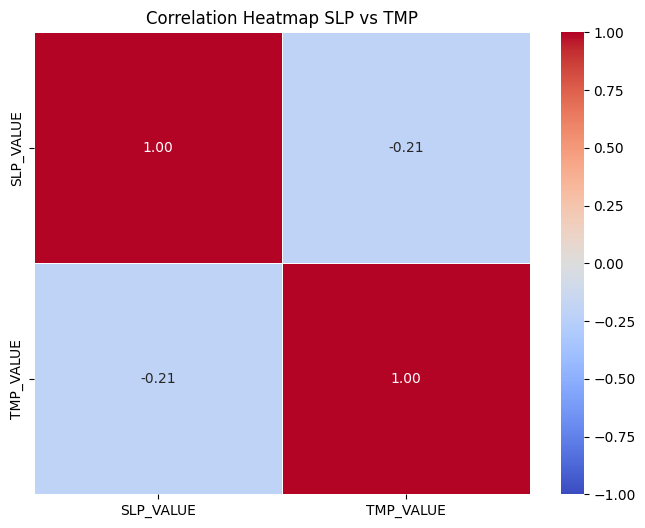

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_SLP, 
            annot=True, 
            cmap = "coolwarm", 
            fmt=".2f", 
            xticklabels=cols,
            yticklabels=cols, 
            linewidths=0.5, 
            vmin=-1,
            vmax=1)
plt.title("Correlation Heatmap SLP vs TMP")
plt.show()

### Correlation of VIS and TMP

In [42]:
# Parsing visibility VIS split

df_VIS_split = df_TEMP_filter.withColumn("VIS", F.split(F.col("VIS"), ",")) \
    .withColumn("VIS_DISTANCE", F.col("VIS").getItem(0).cast(T.FloatType()))\
    .withColumn("VIS_DISTANCE_QUALITY", F.col("VIS").getItem(1).cast(T.IntegerType()))\
    .withColumn("VIS_VARIABILITY", F.col("VIS").getItem(2))\
    .withColumn("VIS_VARIABILITY_QUALITY", F.col("VIS").getItem(3).cast(T.IntegerType()))\
    .drop("VIS")

In [43]:
df_VIS_clean = df_VIS_split.filter((F.col("VIS_DISTANCE") >= 0) & (F.col("VIS_DISTANCE") <= 160000))\
    .filter(F.col("VIS_DISTANCE_QUALITY").isin([0,1,4,5,9]))\
    .drop("VIS_DISTANCE_QUALITY")\
    .filter(F.col("VIS_VARIABILITY").isin(['V', 'N'])) \
    .filter(F.col("VIS_VARIABILITY_QUALITY").isin([0,1,4,5,9]))\
    .drop("VIS_VARIABILITY_QUALITY")


In [31]:
df_VIS_clean.count()

30866793

In [32]:
df_VIS_clean.printSchema()

root
 |-- DATE: string (nullable = true)
 |-- LATITUDE: string (nullable = true)
 |-- LONGITUDE: string (nullable = true)
 |-- ELEVATION: string (nullable = true)
 |-- WND: string (nullable = true)
 |-- CIG: string (nullable = true)
 |-- DEW: string (nullable = true)
 |-- SLP: string (nullable = true)
 |-- TMP_VALUE: float (nullable = true)
 |-- VIS_DISTANCE: float (nullable = true)
 |-- VIS_VARIABILITY: string (nullable = true)



In [34]:
df_VIS_clean.groupBy('VIS_VARIABILITY').count().show()

+---------------+--------+
|VIS_VARIABILITY|   count|
+---------------+--------+
|              V|  174095|
|              N|30692698|
+---------------+--------+



In [44]:
df_VIS_clean = df_VIS_clean.withColumn(
    "VIS_VARIABILITY_NUM",
    F.when(F.col("VIS_VARIABILITY") == "V", 1).otherwise(0).cast(T.FloatType())
)

In [45]:
# Columns
cols = ["VIS_DISTANCE", "VIS_VARIABILITY_NUM", "TMP_VALUE"]

# Compute correlation matrix in Spark
corr_matrix_VIS = []
for i in range(len(cols)):
    row = []
    for j in range(len(cols)):
        corr_val = df_VIS_clean.stat.corr(cols[i], cols[j])
        row.append(corr_val)
    corr_matrix_VIS.append(row)

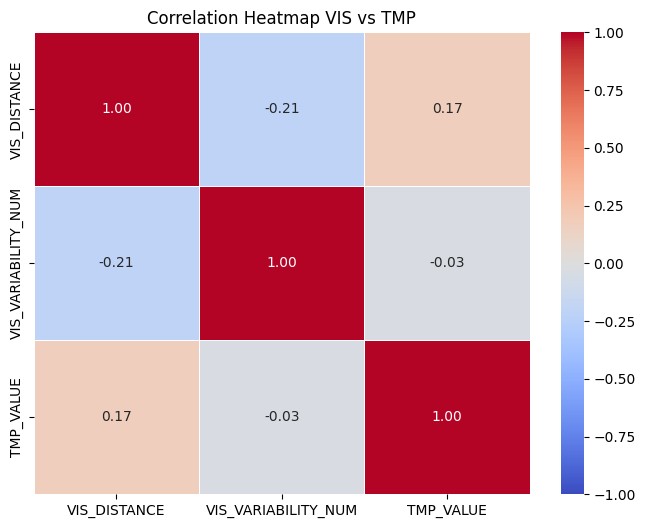

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_VIS, 
            annot=True, 
            cmap = "coolwarm", 
            fmt=".2f", 
            xticklabels=cols, 
            yticklabels=cols, 
            linewidths=0.5, 
            vmin=-1, 
            vmax=1)
plt.title("Correlation Heatmap VIS vs TMP")
plt.show()

In [28]:
df_VIS_distance_only = df_VIS_split.filter((F.col("VIS_DISTANCE") >= 0) & (F.col("VIS_DISTANCE") <= 160000))\
    .filter(F.col("VIS_DISTANCE_QUALITY").isin([0,1,4,5,9]))

In [29]:
df_VIS_distance_only.count()

84243841

In [44]:
vis_dist_corr_value = df_VIS_distance_only.stat.corr("VIS_DISTANCE", "TMP_VALUE")
print("Correlation between VIS Distance and TMP: ", vis_dist_corr_value)

Correlation between VIS Distance and TMP:  -0.046757796433045756


In [45]:
df_VIS_variability_only = df_VIS_split.filter(F.col("VIS_VARIABILITY").isin(['V', 'N'])) \
    .filter(F.col("VIS_VARIABILITY_QUALITY").isin([0,1,4,5,9]))

In [47]:
df_VIS_variability_only = df_VIS_variability_only.withColumn(
    "VIS_VARIABILITY_NUM",
    F.when(F.col("VIS_VARIABILITY") == "V", 1).otherwise(0).cast(T.FloatType())
)

In [49]:
vis_var_corr_value = df_VIS_variability_only.stat.corr("VIS_VARIABILITY_NUM", "TMP_VALUE")
print("Correlation between VIS Variability and TMP: ", vis_var_corr_value)

Correlation between VIS Variability and TMP:  -0.03342210032374208


### Correlation of Dew and TMP

In [13]:
# Parsing Dew
df_DEW_split = df_TEMP_filter.withColumn('DEW' , F.split(F.col("DEW"), ",")) \
.withColumn('DEW_VALUE', F.col('DEW').getItem(0).cast(T.FloatType())) \
.withColumn('DEW_QUALITY', F.col('DEW').getItem(1)).drop('DEW')

In [15]:
df_DEW_clean = df_DEW_split.filter((F.col('DEW_VALUE') >= -982) & (F.col('DEW_VALUE') <= 368)) \
.filter(F.col('DEW_QUALITY').isin(['0','1','4','5','9','A', 'C', 'I' ,'M', 'P', 'R', 'U'])) \
.drop('DEW_QUALITY')

In [17]:
dew_tmp_corr_value = df_DEW_clean.stat.corr("DEW_VALUE", "TMP_VALUE")
print("Correlation between DEW and TMP: ", dew_tmp_corr_value)

Correlation between DEW and TMP:  0.853561526664373


In [18]:
# Columns
cols = ["DEW_VALUE", "TMP_VALUE"]

# Compute correlation matrix in Spark
corr_matrix_DEW = []
for i in range(len(cols)):
    row = []
    for j in range(len(cols)):
        corr_val = df_DEW_clean.stat.corr(cols[i], cols[j])
        row.append(corr_val)
    corr_matrix_DEW.append(row)


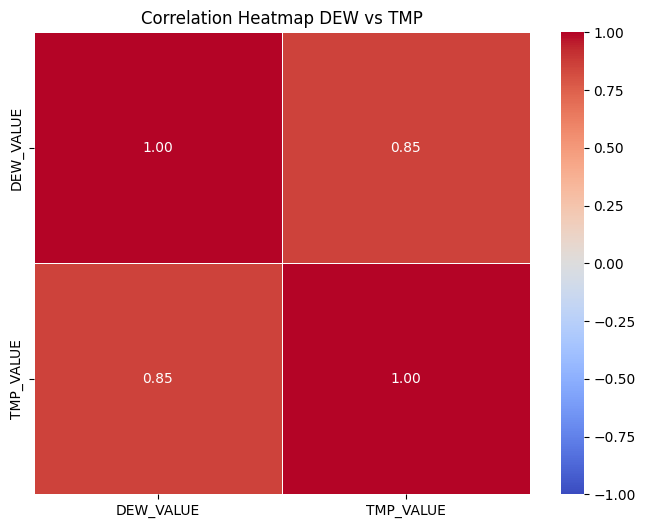

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_DEW,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=cols,
    yticklabels=cols,
    linewidths=0.5,
    vmin=-1,   # Set lower bound of color scale
    vmax=1    # Set upper bound of color scale
)
plt.title("Correlation Heatmap DEW vs TMP")
plt.show()
